Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.
***

На этой теме мы завершаем _«базовый анализ»_ и после перейдем к работе с данными в машинном обучении (в каком-то виде). Поэтому это домашнее задание **подводит итог всем предыдущим** и добавляет красивую вишенку на тортике в виде динамической визуализации.

**Что это означает для вас?**  
Это означает, что при работе с данными ожидаются все те же шаги, что вы делали ранее, а именно
- [x] анализ проблем,
- [x] работа с пропусками,
- [x] работа с аномалиями,
- [x] нормальные текстовые выводы и объяснения проделанных махинаций.

Это не означает, что нужно нагромождать много кода. Это значит, что нужно уделить этому время и _**аккуратно, компактно отразить это в итоговой версии ноутбука**_. Если никаких проблем или махинаций нет, то об этом тоже нужно написать и _**объяснить, почему вы такие решения приняли**_.

# Введение и требования

Прежде чем перейти к заданиям, давайте разберёмся с теоретическими основами динамической визуализации и _**техническими требованиями к сдаче**_.

**Почему интерактивные графики лучше статических?**

Динамические графики позволяют быстро без дополнительного кода выбрать «ракурс» обзора данных:
- приближение,
- показ конкретного значения,
- фильтрация,
- сравнение.
  
Эти возможности позволяют делать анализ более понятным и быстрым для внешнего пользователя (вы как аналитик скорее всего будете кому-то представлять результаты аналитики, для этого и нужны нормальные текстовые выводы).

**Когда использовать динамическую визуализацию?**

Понятно, что для вас как для аналитика будет достаточно и обычных графиков, если вы научились их быстро и качественно делать, однако плюсы динамики именно в удобном представлении без глубокого погружения для взгляда со стороны.
* Дашборды для бизнес-пользователей
* EDA для представления вне
* Презентации с глубоким погружением
* Публикации в вебе

В этом задании мы (вы) поработаем с двумя библиотеками, позволяющими делать динамическую визуализацию: `plotly` и `bokeh`.  
Как всегда в задании будет теория, но вот ваша любимая полная документация по [плотли](https://plotly.com/python/plotly-express/?spm=a2ty_o01.29997173.0.0.3ef45171As9d36) и
[боке](https://docs.bokeh.org/en/latest/docs/user_guide.html?spm=a2ty_o01.29997173.0.0.2aa45171z7LipR).
***

Хотя динамическая визуализация и хороша, но с ней не все  так просто, как хотелось бы

<div class="alert alert-danger">
Гитхаб (да и вообще все без подключения к ядру) <b>не отображает интерактивные графики</b>! Отображаться может только статическое превью или вообще не отображаться ничего.
</div>

Поэтому в этом задании есть определенные **ТРЕБОВАНИЯ** к сдаче:

1. Графики в каждом задании **необходимо сохранять в формате `html`**.
   
   ```python
    import plotly.graph_objects as go
    fig = go.Figure(...)
    fig.write_html("visualization.html")  # Сохраняет полный интерактив

    from bokeh.plotting import output_file, save
    output_file("dashboard.html")
    save(fig)  # Сохраняет дашборд как HTML  
   ```  

   Подробнее про сохранение будет в каждом задании.
2. Помимо ноутбука необходимо **загрузить сохраненные `html` графики**.  
   Если вы сдаете в **github**, то нужно
   - создать отдельную папку для графиков и загрузить их туда,
   - в ридми объяснить структуру и какой график относится к какому заданию, также добавить скриншоты графиков.
     
   Если вы сдаете в **google Colab**, то нужно
   - загрузить графики куда-нибудь к себе на диск так, чтобы был доступ,
   - в конце каждого задания вставить ссылку на `html` и скрин графика.

Пожалуйста, сделайте так, чтобы все было понятно и у всего были адекватные и емкие пояснения.

# Данные

Как в прошлом задании тема была выбрана как что-то, что может быть полезным при работе аналитиком, так и тут мы затронем интересную тему. Будем работать с **временными рядами** — последовательностями данных, упорядоченных во времени. 

Для работы с этим заданием мы возьмем финансовые данные американского рынка в период `start='2021-01-01', end='2024-12-31'`. 
> Это не стандартный датасет, он специально подготовлен для задания. Если интересно,то он загружен с помощью [библиотеки](https://pypi.org/project/yfinance/) `yfinance` примерно следующими махинациями.
```python
tickers = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA', '^GSPC']
...
df_temp = stock.history(start='2021-01-01', end='2024-12-31')
...
df_temp = df_temp.rename(columns={
        'Open': 'Open',
        'High': 'High', 
        'Low': 'Low',
        'Close': 'Close',
        'Volume': 'Volume',
        'Date': 'Date'
    })
```

В дататасете есть 9 следующих **колонок**:
- `Date` — дата торговой сессии,
- `Open` — цена первой сделки дня,
- `High` — самая высокая цена за день,
- `Low` — самая низкая цена за день,
- `Close` — цена последней сделки,
- `Volume` — количество проданных акций,
- `Dividends` — выплаты дивидендов,
- `Stock Splits` — дробление/консолидация акций,
- `Ticker` — биржевой символ компании.

_Не сильно шарю в финансах, могла ошибиться, буду рада, если поправите._

Также, чтобы вы не искали приведу и **расшифровку тикеров**:
- `AAPL` — Apple Inc.,
- `GOOGL` — Alphabet Inc. то есть Google,
- `MSFT` — Microsoft Corporation,
- `AMZN` — Amazon.com  Inc.,
- `TSLA` — Tesla Inc.,
- `^GSPC` — S&P 500.

In [1]:
import pandas as pd

df = pd.read_csv('stocks_2021_2024.csv')
df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.tz_localize(None)
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2021-01-04 05:00:00,129.853846,129.941372,123.279459,125.856697,143301900,0.0,0.0,AAPL
1,2021-01-05 05:00:00,125.350958,128.122709,124.903582,127.412743,97664900,0.0,0.0,AAPL
2,2021-01-06 05:00:00,124.213113,127.451681,122.909903,123.123863,155088000,0.0,0.0,AAPL
3,2021-01-07 05:00:00,124.835528,128.015745,124.349256,127.325233,109578200,0.0,0.0,AAPL
4,2021-01-08 05:00:00,128.793735,128.988255,126.654145,128.424179,105158200,0.0,0.0,AAPL


In [2]:
df.Ticker.unique()

<StringArray>
['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'TSLA', '^GSPC']
Length: 6, dtype: str

In [3]:
# Проведите базовый анализ, чтобы познакомиться с данными
print(df.shape)
print("типы данных:\n", df.dtypes)
print("количество уникальных значений:\n", df.nunique())

print("пропуски")

print(df.isna().sum())

print("дубликаты\n", df.duplicated().sum())


(6024, 9)
типы данных:
 Date            datetime64[us]
Open                   float64
High                   float64
Low                    float64
Close                  float64
Volume                   int64
Dividends              float64
Stock Splits           float64
Ticker                     str
dtype: object
количество уникальных значений:
 Date            1004
Open            5935
High            5939
Low             5957
Close           5927
Volume          6000
Dividends         12
Stock Splits       3
Ticker             6
dtype: int64
пропуски
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
Ticker          0
dtype: int64
дубликаты
 0


In [4]:
print("базовые характеристики:\n")
df.describe() 

базовые характеристики:



,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,6024,6024.000000,6024.000000,6024.000000,6024.000000,6.024000e+03,6024.000000,6024.000000
mean,2022-12-31 15:46:04.541832,919.956776,926.379614,913.267950,920.131667,7.554372e+08,0.002494,0.007138
min,2021-01-04 05:00:00,82.800003,83.480003,81.430000,81.820000,0.000000e+00,0.000000,0.000000
25%,2021-12-30 23:00:00,145.255585,146.839365,143.748695,145.336380,3.152960e+07,0.000000,0.000000
50%,2022-12-29 17:00:00,193.489027,196.240740,190.826438,193.275261,5.883660e+07,0.000000,0.000000
75%,2023-12-30 05:00:00,322.410289,325.413757,317.933854,321.669434,1.091818e+08,0.000000,0.000000
max,2024-12-30 05:00:00,6089.029785,6099.970215,6079.979980,6090.270020,9.976520e+09,0.830000,20.000000
std,NaN,1630.645618,1638.857632,1621.944737,1630.930251,1.602480e+09,0.036931,0.366425


### Вывод по базовому анализу датасета:

В датасете представлены акции всего шести комнаний. В датасете нет полностью повторяющихся строк и пропусков. 

# Задание 1: базовая визуализация (3 pt)

Прежде, чем приступить к визуалиции разберемся, что умеет базово делать `plotly`.

| Возможность | Параметр/метод | Что делает | Возможные значения |
| :---------- | :------------- | :--------- | :----------- |
| **Range Slider** | `.update_xaxes(rangeslider=)` | Ползунок для быстрого выбора периода | [это словарь с кучей параметров](https://plotly.com/python/reference/layout/xaxis/#layout-xaxis-rangeslider:~:text=the%20range%20selector.-,rangeslider,-Code%3A%20fig) |
| **Range Selector** | `.update_xaxes(rangeselector=)` | Кнопки для предопределённых периодов (1M, 3M, 1Y, All) | [это тоже словать с кучей параметров](https://plotly.com/python/reference/layout/xaxis/#layout-xaxis-rangeslider:~:text=to%20linear%20axes.-,rangeselector,-Code%3A%20fig) |
| **Hover** | `.update_layout(hovermode=)` | Точные значения при наведении курсора | [про hover в целом](https://plotly.com/python/hover-text-and-formatting/) |
| **Zoom/Pan** | Встроено по умолчанию | Детальное изучение любых участков графика | делается колесиком, перетаскиванием, кликом (где как) |
| **Export** | `fig.write_html()` / `fig.write_image()` | Сохранение графика как PNG/HTML | [про html](https://plotly.com/python/interactive-html-export/) |

Логика **основных компонентов `plotly figure`** примерно такая
```python
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 0. Создание фигуры
fig = go.Figure()
fig = make_subplots(...) # или так

# 1. Добавление данных (traces)
fig.add_trace(go.Candlestick(...))
fig.add_trace(go.Scatter(...))

# 2. Настройка layout
fig.update_layout(
    title="Заголовок",
    xaxis_rangeslider_visible=True,
    hovermode='x unified'
)

# 3. Сохранение
fig.write_html("output.html")
```

При этом каждая функция имеет огромное количество параметров, важно не перегрузить ими график.  
Пойдем по каждому из шагов.
***

#### Создание фигуры

Фигуру можно создать двумя способами:
* `fig = go.Figure()` — простая фигура (один график);
* `fig = make_subplots(...) — подграфики (несколько графиков в одном)`

В этой части мы сразу поработаем с **[подграфиками](https://plotly.com/python-api-reference/generated/plotly.subplots.make_subplots.html)**.

У этой функции следующие _основные_ параметры, поймите, какие для вас важны.

| Параметр | Тип | Что задает |
|:-------- | :-- | :--------- |
| `rows` | int | Количество рядов |
| `cols` | int | Количество колонок |
| `shared_xaxes` | bool | Общая ось X |
| `shared_yaxes` | bool | Общая ось Y |
| `vertical_spacing` | float | Отступ по вертикали |
| `horizontal_spacing` | float | Отступ по горизонтали |
| `row_heights` | list | Высота рядов (доли) |
| `column_widths` | list | Ширина колонок (доли) |
| `subplot_titles` | list | Заголовки подграфиков |

***

#### Добавление данных

Так как тут мы работаем с вполне конкретными финансовыми данными разберем 3 (4) **вида графиков**, которые нам могут пригодиться.

**[Свечной график](https://plotly.com/python/candlestick-charts/?spm=a2ty_o01.29997173.0.0.2aa45171z7LipR) (`Candlestick`)**  

Он нужен для отражения **изменения цены актива** за выбранный промежуток времени. Одна свеча показывает четыре ключевых ценовых показателя: цену открытия, закрытия, максимум и минимум.

Основные параметры у этого дела такие:
- `x` — даты/время,
- `open` — цена открытия,
- `high` — максимум дня,
- `low` — минимум дня,
- `close` — цена закрытия,
- `name` — название в легенде,
- `increasing_line_color` — цвет растущей свечи,
- `decreasing_line_color` — цвет падающей свечи,
- `hovertemplate` — шаблон подсказки при точечном рассмотрении.

**[Линейный график](https://plotly.com/python-api-reference/generated/plotly.graph_objects.Scatter.html) (`Scatter`)**

Привычный нам график, отрисовки линии можно добиться, меняя параметр `mode`.

- `x` — ось X,
- `y` — ось Y,
- `name` — название в легенде,
- `mode` — режим отображения (`'lines'`, `'markers'`, `'lines+markers'`),
- `line` — настройки линии,
- `marker` — настройки маркеров.

**[Столбчатый график](https://plotly.com/python-api-reference/generated/plotly.graph_objects.Bar.html) (`Bar`)**

Привычная нам столбчатая диаграмма с основными параметрами
- `x` — ось X,
- `y` — ось Y (значения),
- `name` — название в легенде,
- `marker_color` — цвет столбцов,
- `opacity` — прозрачность,
- `width` — ширина столбцов.

Добавление графиков на фигуру можно делать при [метода](https://plotly.com/python-api-reference/generated/generated/plotly.graph_objects.Figure.add_traces.html) `fig.add_trace()`.

***

#### Настройки графика

Настройка графиков производится разными методами, разберем основные из них

**Базовая настройка [layout](https://plotly.com/python/reference/layout/) `update_layout`**

С помощью этого метода делается базовая настройка внешнего вида графика. Параметров много, основные такие:
- `title` — заголовок графика,
- `height` — высота фигуры,
- `width` — ширина фигуры,
- `hovermode` — режим hover,
- `showlegend` — показывать ли легенду,
- `template` — тема оформления,
- `plot_bgcolor` — цвет фона графика,
- `margin` — отступы,
- `legend` — настройки легенды.

**[Настройка осей](https://plotly.com/python/reference/layout/xaxis/) (`update_xaxes`/`update_yaxes`)**

параметры для оси X `update_xaxes`:
- `rangeselector` — кнопки выбора периода,
- `rangeslider` — ползунок периода,
- `title` — название оси,
- `tickformat` — форма меток,
- `tickangle` — угол наклона меток,
- `row`, `col` — для **подграфиков**.

Для оси Y `update_yaxes` практически [аналогично](https://plotly.com/python/reference/layout/yaxis/).

**[Добавление аннотаций](https://plotly.com/python/text-and-annotations/) `add_annotation`**

иногда полезно добавлять на график какие-то метки, которые покажут дополнительную информацию, например информацию о внешних событиях (анонсы, торги, мировые события и т.д.)

```python
fig.add_annotation(
    x='2024-02-01',
    y=185.50,
    text='Чей-то отчет',
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=2,
    arrowcolor='green',
    ax=0,
    ay=-60,
    bgcolor='white',
    bordercolor='black',
    borderwidth=1,
    font=dict(size=9),
    row=1,
    col=1
)
```

***

In [5]:
!pip install plotly


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Сохранение

Ну и, наконец, после того, как вы все нарисовали нужно это **сохранить**.  

Метод `fig.show()` как и привычно отобразит график, но иногда это отображение может быть косячным (не влезать в ноутбук, не работают фичи в редакторе и все такое). Поэтому надо уметь **сохранять с сохранением интерактивности.**

Для этого существует метод `write_html`, который позволяет сохранить динамический формат и открыть его в браузере. Можно сильно не играться с параметрами, но на всякий случай вот они
- `file` — путь к файлу, в который сохранять,
- `include_plotlyjs` — встроить ли библиотеку,
- `full_html` — полный ли HTML документ,
- `config` — настройки,
- `auto_open` — открыть ли в браузере.
***

### Скользящее среднее

Это не пункт из создания графика, но важное знание при работе с временными рядами.  

**[Скользящее среднее (MA)](https://ru.wikipedia.org/wiki/%D0%A1%D0%BA%D0%BE%D0%BB%D1%8C%D0%B7%D1%8F%D1%89%D0%B0%D1%8F_%D1%81%D1%80%D0%B5%D0%B4%D0%BD%D1%8F%D1%8F)** — усреднение значений за определённый период, сдвигающийся во времени. Оно нужно для того, чтобы например отсматривать сигналы (для финансов), **определять тренд** как краткосрочный, так и долгосрочный.

**Простое скользящее среднее** считается так
$$SMA_t = \frac{1}{n} \sum\limits_{i=0}^{n-1} p_{t-1},$$
то есть как среднее по окну.

Скользящее среднее можно считать по разному, но мы в нашем задании ограничимся простым. Для подсчета его в пандасе как раз есть [штука](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html) `.rolling`, которая вам поможет.

## Задание (3 pt)

В этом задании нужно сделать следующее и в качестве результата предъявить **интерактивный график** и **ВЫВОДЫ**, которые вы по нему сделали (они не обязаны быть большими, но должны быть емкими и нормально сформулированными).
1. Выберите **одну из компаний**, чьи активы хотите проанализировать (_это пойдет и во второе задание_).
2. Сделайте **подграфики**, связанные по оси X:
   * на верхнем отобразите **динамику цен** при помощи **свечного графика**,
   * на нижнем отобразите **динамику объема** при помощи **столбчатой диаграммы**.
3. Добавьте **ползунок выбора периода** снизу для грацика цен.
4. Добавьте **кнопки выбора периода** за 1 месяц, 3 месяца, 6 месяцев, год и все время.
5. Добавьте **hover** с деталями о значениях цен (открытия, закрытия, мин и макс) и объема.
6. Добавьте два **скользящих средних**: `MA-5` и `MA-20`.
7. Добавьте в качестве **аннотаций минимум 3 важных для рынка события** (дивиденды, отчеты, презентации новых продуктов или что-то подобное).

_Каждый пункт, кроме первого оценивается в 0,5 pt._  
Должно получиться что-то такое (события расположены абсолютно рандомно, я не гуглила)

<img src="attachment:98f48189-632f-4b07-a622-bd6cb97770e5.png" alt="Общий вид графика" width="800">  

<img src="attachment:b65adb4a-a0f6-4674-964a-e577c25c874c.png" alt="Общий вид графика" width="400"> <img src="attachment:506f63ce-0e8e-48e7-a885-6cf8a3fa04c5.png" alt="Общий вид графика" width="400">

_Для удобства вам дан некоторый шаблон (то, как делала я), но вы можете менять его по своему усмотрению._

In [6]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from datetime import datetime

TICKER = "AAPL" # Выберите одну компанию
df_stock = df[df['Ticker'] == TICKER].copy()
df_stock = df_stock.sort_values('Date').reset_index(drop=True)

# Посчитайте скользящее среднее
df_stock['MA5'] = df_stock['Close'].rolling(window=5).mean()
df_stock['MA20'] = df_stock['Close'].rolling(window=20).mean()

# Задайте события, надо погуглить
# События для Apple (даты важных отчётов, презентаций, дивидендов)
EVENTS = [
    {"date": "2021-04-28", "text": "Квартальный отчёт", "color": "green"},
    {"date": "2021-09-14", "text": "Презентация iPhone 13", "color": "orange"},
    {"date": "2023-06-05", "text": "WWDC 2023 (Vision Pro)", "color": "red"},
]

annotated_events = []
for event in EVENTS:
    event_date = pd.to_datetime(event['date'])
    # Находим ближайшую торговую дату, вдруг ее нет в датасете
    closest_idx = (df_stock['Date'] - event_date).abs().idxmin()
    price_at_event = df_stock.loc[closest_idx, 'Close']
    event_date_actual = df_stock.loc[closest_idx, 'Date']
    
    annotated_events.append({
        'date': event_date_actual,
        'price': price_at_event,
        'text': event['text'],
        'color': event['color']
    })

In [7]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from datetime import datetime

TICKER = "AAPL" # Выберите одну компанию
df_stock = df[df['Ticker'] == TICKER].copy()
df_stock = df_stock.sort_values('Date').reset_index(drop=True)

# Посчитайте скользящее среднее
df_stock['MA5'] = df_stock['Close'].rolling(window=5).mean()
df_stock['MA20'] = df_stock['Close'].rolling(window=20).mean()

# Задайте события, надо погуглить
# События для Apple (даты важных отчётов, презентаций, дивидендов)
EVENTS = [
    {"date": "2021-04-28", "text": "Квартальный отчёт (Q2 2021)", "color": "green"},
    {"date": "2021-09-14", "text": "Презентация iPhone 13", "color": "orange"},
    {"date": "2022-06-06", "text": "WWDC 2022 (iOS 16, M2)", "color": "purple"},
    {"date": "2022-09-07", "text": "Презентация iPhone 14 и Apple Watch Ultra", "color": "blue"},
    {"date": "2023-06-05", "text": "WWDC 2023 (Vision Pro)", "color": "red"},
    {"date": "2023-09-12", "text": "Презентация iPhone 15 (USB-C)", "color": "orange"},
    {"date": "2024-02-01", "text": "Квартальный отчёт (Q1 2024) – рекорд $119,6 млрд", "color": "green"},
    {"date": "2024-06-10", "text": "WWDC 2024 (Apple Intelligence)", "color": "purple"},
]

annotated_events = []
for event in EVENTS:
    event_date = pd.to_datetime(event['date'])
    # Находим ближайшую торговую дату, вдруг ее нет в датасете
    closest_idx = (df_stock['Date'] - event_date).abs().idxmin()
    price_at_event = df_stock.loc[closest_idx, 'Close']
    event_date_actual = df_stock.loc[closest_idx, 'Date']
    
    annotated_events.append({
        'date': event_date_actual,
        'price': price_at_event,
        'text': event['text'],
        'color': event['color']
    })

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,       
    vertical_spacing=0.05,      
    row_heights=[0.7, 0.3],     
    subplot_titles=('Цена акции Apple (AAPL)', 'Объём торгов')
)
# Добавление цен
fig.add_trace(
    go.Candlestick(
        x=df_stock['Date'],
        open=df_stock['Open'],
        high=df_stock['High'],
        low=df_stock['Low'],
        close=df_stock['Close'],
        name='Свечи',
        increasing_line_color='green',
        decreasing_line_color='red',
        hovertext='Цена'
    ),
    row=1, col=1
)

# Добавление MA-5
fig.add_trace(
    go.Scatter(
        x=df_stock['Date'],
        y=df_stock['MA5'],
        name='MA-5',
        line=dict(color='blue', width=1.5),
        mode='lines'
    ),
    row=1, col=1
)

# Добавление MA-20
fig.add_trace(
    go.Scatter(
        x=df_stock['Date'],
        y=df_stock['MA20'],
        name='MA-20',
        line=dict(color='orange', width=2, dash='dash'),
        mode='lines'
    ),
    row=1, col=1
)

# Добавление объема
fig.add_trace(
    go.Bar(
        x=df_stock['Date'],
        y=df_stock['Volume'],
        name='Объём',
        marker_color='gray',
        opacity=0.7,
        hovertemplate='Дата: %{x}<br>Объём: %{y:,.0f}<extra></extra>'
    ),
    row=2, col=1
)

# Добавление событий
for event in annotated_events:
    fig.add_annotation(
        x=event['date'],
        y=event['price'],
        text=event['text'],
        showarrow=True,
        arrowhead=2,
        arrowsize=1,
        arrowwidth=2,
        arrowcolor=event['color'],
        ax=0,
        ay=-40,                      
        bgcolor='white',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=10, color=event['color']),
        row=1, col=1
    )


# Общая настройка вида
fig.update_layout(
    title='Динамика цены и объёма торгов Apple (AAPL) с 2021 по 2024',
    template='plotly_white',
    height=800,
    width=1200,
    hovermode='x unified',          
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(t=80, b=60)
)

# Настройка Range Selector и range Slider
fig.update_xaxes(
    rangeselector=dict(
        buttons=list([
            dict(count=1, label='1м', step='month', stepmode='backward'),
            dict(count=3, label='3м', step='month', stepmode='backward'),
            dict(count=6, label='6м', step='month', stepmode='backward'),
            dict(count=1, label='1г', step='year', stepmode='backward'),
            dict(step='all', label='Всё время')
        ]),
        font=dict(size=12),
        bgcolor='lightgray',
        activecolor='lightblue'
    ),
    rangeslider=dict(visible=True, thickness=0.05),
    title='Дата',
    tickformat='%Y-%m-%d',
    row=1, col=1
)

# Настройка оси X для графика объёма
fig.update_xaxes(
    title='Дата',
    tickformat='%Y-%m-%d',
    row=2, col=1
)

# Настройка осей Y
fig.update_yaxes(title_text='Цена (USD)', row=1, col=1)
fig.update_yaxes(title_text='Объём (акций)', row=2, col=1)


In [8]:
# Сохранение
fig.write_html("task1_aapl.html", include_plotlyjs=True, full_html=True)

### События:
**Квартальный отчёт (Q2 2021)** – публикация финансовых результатов Apple за второй квартал 2021 года. 

**Презентация iPhone 13** – сентябрьское мероприятие, где представили новое поколение смартфонов.

**WWDC 2022 (iOS 16, M2)** – ежегодная конференция разработчиков, на которой анонсировали новые операционные системы и процессор M2. 

**Презентация iPhone 14 и Apple Watch Ultra** – осенний анонс новых iPhone и первых «ультра» часов. 

**WWDC 2023 (Vision Pro)** – презентация гарнитуры смешанной реальности Vision Pro – первого крупного нового продукта Apple за много лет.

**Презентация iPhone 15 (USB-C)** – выход iPhone с переходом на USB-C, значительное изменение в дизайне, что привлекло внимание потребителей и инвесторов.

**Квартальный отчёт (Q1 2024) – рекорд $119,6 млрд** – отчёт за первый квартал 2024 года, где Apple объявила о рекордной выручке, во многом благодаря продажам Vision Pro и iPhone.

**WWDC 2024 (Apple Intelligence)** – анонс генеративных ИИ‑функций в iOS и других ОС. 

**НАПИШИТЕ ВЫВОДЫ ПОСЛЕ АНАЛИЗА ГРАФИКА**

Рассмотрим ключевые события:

после квартаольного отчета в 2021 года акции упали, после презентации айфона 13 акции также упали, после конференции и презентации айфона 14 акции упали, после квартрального отвеча с рекордной выручкой акции также упали. Они начали расти только после анонсирования ии функций. Также был есть явный тренд в период  с октября 2023 по октрябрь 2024. Вероятно такой линейный возрастающий тренд связан с ажиотажем вокруг apple vision. В целом за все время виден возрастающий тренд. Интересно, что после выхода новых айфонов акции падают, но там же что-то происходит с тем, что старые линейки становятся сильно дешевле, может поэтому инвесторам не очень нравится этот период, а может быть из-за того, что каждый год от эпл ждут каких-то инновационных гаджетов, а они добавляют одну камеру или увеличивают диагональ на 0.00001 мм, поэтому после презентации акции падают. 

# Задание 2: сезонность (2 pt)

#### Необходимая информация

**Сезонность** — это повторяющиеся паттерны во временном ряду, которые возникают через фиксированные промежутки времени. Само по себе слово общее, под ним могут понимать разное, поэтому давайте разделим.
***

* **Тренд** — долгосрочное направление движения значений.
* **Сезонность** — периодические колебания в определенное время (например перед праздниками). Может быть
  - _**дневная**_ (привязана к часам),
  - _**недельная**_ (призана к дням недели),
  - _**месячная**_ (может быть привязана к отчетному периоду или времени выплат),
  - _**годовая**_ (привязана к месяцам и важным событиям).
* **Цикл** — долгосрочные колебания без фиксированного периода
* **Остаток** — случайные колебания (шум).

Тогда значения во временном ряду можно **декомпозировать**, например, как сумму тренда, сезонности и остатка.

Мы не будем подробно разбирать декомпозицию, тут нам достаточно знать, что есть замечательная библиотека `statsmodels`, в которой реализованы методы, которые умеют выделять сезонность:
- [классическая](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) декомпозиция в `seasonal_decompose`,
- [более умная](https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.STL.html) декомпозиция в `STL`.

```python
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df['Close'],
    model='additive',    # 'additive' или 'multiplicative'
    period=251           # Количество торговых дней в году
)
```
***
В этом задании нам пригодятся еще один вид графиков `go.Heatmap()`.

**[Тепловая карта](https://plotly.github.io/plotly.py-docs/generated/plotly.graph_objects.Heatmap.html) `go.Heatmap()`**

```python
fig = go.Figure(data=go.Heatmap(
    z=pivot_table.values,
    x=pivot_table.columns,
    y=pivot_table.index,
    colorscale='...',
    hovertemplate='Месяц: %{y}<br>День: %{x}<br>Доходность: %{z:.2f}'
))
```

## Задание (2 pt)

В этом пункте вам нужно сделать **два интерактивных графика и ВЫВОДЫ** по ним.
1. На первом графике отобразите **4 вида информации** (для каждой свой подграфик):
   * временной ряд _**цены закрытия**_,
   * **тренд** из разложения,
   * **сезонность** из разложения,
   * **остаток** разложения.
2. На втором графике отобразите **тепловую карту доходности по дням недели и месяцам**. То есть посчитайте, доходность в зависимости от месяца и дня недели в нем.
3. Для обоих графиков настройте парметры **zoom** и **hover**.

_Каждый график оценивается в 1 pt._  
Должно получиться что-то такое

<img src="attachment:2f383d72-7941-4d6c-be2a-f06e55792e4c.png" alt="Общий вид графика" width="800">  

<img src="attachment:5662010c-67ad-4da1-9f24-27b706ae4202.png" alt="Общий вид графика" width="800">

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_stock = df[df['Ticker'] == TICKER].copy()
df_stock = df_stock.sort_values('Date').reset_index(drop=True)

# Выделите фичи
df_stock['Year'] = df_stock['Date'].dt.year
df_stock['Month'] = df_stock['Date'].dt.month
df_stock['MonthName'] = df_stock['Date'].dt.strftime('%B')
df_stock['DayOfWeek'] = df_stock['Date'].dt.dayofweek
df_stock['DayName'] = df_stock['Date'].dt.strftime('%A')
df_stock['WeekOfYear'] = df_stock['Date'].dt.isocalendar().week

# Процент доходности по сравнению с прошлым днем
df_stock['Return'] = df_stock['Close'].pct_change() * 100

# Используйте простой вариант
decomposition = seasonal_decompose(
    df_stock['Close'],
    model='additive',
    period=251
)

# Извлечение компонентов
df_stock['Trend'] = decomposition.trend
df_stock['Seasonality'] = decomposition.seasonal
df_stock['Residual'] = decomposition.resid

In [10]:
df_stock.head(3)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Year,Month,MonthName,DayOfWeek,DayName,WeekOfYear,Return,Trend,Seasonality,Residual
0,2021-01-04 05:00:00,129.853846,129.941372,123.279459,125.856697,143301900,0.0,0.0,AAPL,2021,1,January,0,Monday,1,NaN,NaN,-0.279471,NaN
1,2021-01-05 05:00:00,125.350958,128.122709,124.903582,127.412743,97664900,0.0,0.0,AAPL,2021,1,January,1,Tuesday,1,1.236363,NaN,-0.992174,NaN
2,2021-01-06 05:00:00,124.213113,127.451681,122.909903,123.123863,155088000,0.0,0.0,AAPL,2021,1,January,2,Wednesday,1,-3.366131,NaN,-2.205401,NaN


In [16]:
# Создание фигуры с 4 подграфиками
fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=('Цена закрытия', 'Тренд', 'Сезонность', 'Остаток')
)

# Цена закрытия
fig.add_trace(
    go.Scatter(
        x=df_stock['Date'],
        y=df_stock['Close'],
        mode='lines',
        name='Цена закрытия',
        line=dict(color='black', width=1.5)
    ),
    row=1, col=1
)

# Тренд
fig.add_trace(
    go.Scatter(
        x=df_stock['Date'],
        y=df_stock['Trend'],
        mode='lines',
        name='Тренд',
        line=dict(color='blue', width=2)
    ),
    row=2, col=1
)

# Сезонность
fig.add_trace(
    go.Scatter(
        x=df_stock['Date'],
        y=df_stock['Seasonality'],
        mode='lines',
        name='Сезонность',
        line=dict(color='green', width=1.5)
    ),
    row=3, col=1
)

# Остаток
fig.add_trace(
    go.Scatter(
        x=df_stock['Date'],
        y=df_stock['Residual'],
        mode='lines',
        name='Остаток',
        line=dict(color='red', width=1.5)
    ),
    row=4, col=1
)

# Настройка layout
fig.update_layout(
    title=f'Декомпозиция временного ряда для {TICKER}',
    height=1000,
    hovermode='x unified',
    template='plotly_white',
    showlegend=True
)

# Настройка осей
fig.update_xaxes(title_text="Дата", tickformat="%Y-%m-%d", tickangle=45, row=4, col=1)
fig.update_yaxes(title_text="Цена (USD)", row=1, col=1)
fig.update_yaxes(title_text="Тренд (USD)", row=2, col=1)
fig.update_yaxes(title_text="Сезонность", row=3, col=1)
fig.update_yaxes(title_text="Остаток", row=4, col=1)
fig.show()
fig.write_html("task2_decomposition.html", include_plotlyjs=True, full_html=True)

In [ ]:
# Подсчет средней доходности по месяцам и дням недели
pivot_table = df_stock.pivot_table(
    values='Return',
    index='MonthName',
    columns='DayName',
    aggfunc='mean'
)

# Порядок месяцев и дней
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

pivot_table = pivot_table.reindex(index=month_order, columns=day_order)

# Создание heatmap
fig = go.Figure(data=go.Heatmap(
    z=pivot_table.values,
    x=pivot_table.columns,
    y=pivot_table.index,
    colorscale='RdBu',
    zmid=0,
    hovertemplate='Месяц: %{y}<br>День: %{x}<br>Доходность: %{z:.2f}%<extra></extra>'
))



# Настройка layout
fig.update_layout(
    title=f"Средняя дневная доходность {TICKER} по дням недели и месяцам",
    xaxis_title="День недели",
    yaxis_title="Месяц",
    height=600,
    template='plotly_white'
)
fig.show()
fig.write_html("task2_heatmap.html", include_plotlyjs=True, full_html=True)

**НАПИШИТЕ ВЫВОДЫ ПОСЛЕ АНАЛИЗА ГРАФИКОВ**

По хитмапе видно, что у понедельника больше всего холодных оттенков во всех месяцах, значит доходность по понедельникам в целом выше, чем в другие дни.

цена закрытия: виден положительный возрастающий тренд. Видна очень сильная сезонность, с периодичностью в год. Пик всегда приходится на июнь-июль, а сильный упадок в марте. по остатку можно только препдположить, что это какие-то несезонные влияния рынка или какие-то внеплановые штуки от эпл, которые как-то влияли на настроение инвестворов 

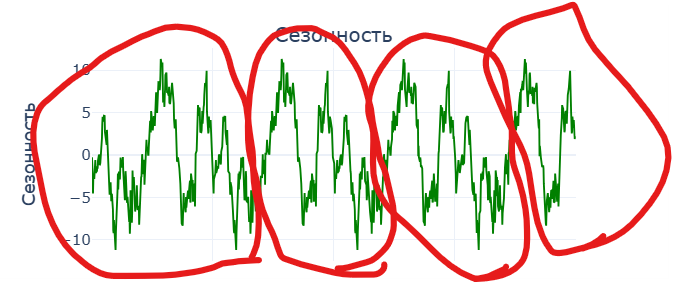

# Задание 3: категории и связанные фильтры (4 pt)

#### Необходимая информация

В предыдущих заданиях вы делали анализ только для одной компании, немного грустно, правда? Давайте в этом задании поработаем именно над отображением и сравнением **всех компаний**.

Не трудно догадаться, что фича «тикер» является **категориальной**, и мы можем это использовать в нашей визуализации.

Начнем немного издалека и поговорим про **cross-filtering**.  
**Cross-filtering** — это техника, при которой взаимодействие с одним графиком влияет на отображение других графиков.

**Типы связей между графиками**

* **Shared Axes** — общая ось X или Y (zoom на одном → zoom на другом),
* **Legend Toggle** — клик на легенде → показать/скрыть (включить/выключить тикер),
* **Brushing** — выделение области → фильтр других (выбрать период → обновить статистику),
* **Click Events** — клик на точке → действие (клик на акции → показать детали),
* **Dropdown** — выбор в меню → обновление (выбрать метрику → изменить график).

То есть вы можете сделать так, чтобы на графике можно было **выбирать, какие компании показывать**: можно посмотреть все, можно отключить некоторые, можно оставить только одну. И более того, вы можете сделать так, чтобы выбор компании **влиял сразу на все подграфики** (обновлял масштаб, внешний вид, значения)!

Лучше идею этого можно посмотреть на картинках

<img src="attachment:10fb7949-fe1a-4bf0-8c79-28a62e4608f6.png" alt="Общий вид графика" width="800"> <img src="attachment:9d916aaa-c2de-4f0f-93fc-20e73ccfb7ad.png" alt="Общий вид графика" width="800">

Подробнее можно почитать [тут](https://dash.plotly.com/interactive-graphing), я же оставлю те куски кода, которые вам могут понадобиться.

**Сложная сетка**

```python
fig = make_subplots(
    rows=2, 
    cols=2,
    shared_xaxes=False,
    shared_yaxes=False,
    ...
    specs=[[{"colspan": 2}, None],  # Row 1: 1 график на 2 колонки
           [{}, {}]]                # Row 2: 2 графика
)
```

**Обновление через меню**
```python
# Dropdown (updatemenus)
fig.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(label="Цена", method="update", args=[...]), # тут можно передать visibility для отключения
                dict(label="Объём", method="update", args=[...])
            ])
        )
    ]
)
```

## Задание (4 pt)

Вам необходимо самостоятельно решить, какую именно информацию о компаниях вы хотите отобразить на графиках, и построить **несколько подграфиков на одной фигуре, связанных между собой**, а также сделать по ним **ВЫВОДЫ**.

Выбор фич полностью остается за вами, однако графики должны соответствовать следующим **трем критериям**:
* Должны быть **кнопки/фильтры выбора компаний**, которые влияют на отображение.
* Должно быть **минимум два связанных графика**, где изменение одного влияет на изменение другого.
* Должны быть минимум **три графика**, отображающие **разную информацию** (разные цены разной информацией не считаются).

Конечно, все это должно сопровождаться **легендой**, **названиями осей** и **hover**.

_Каждый пункт и выводы оцениваются в 1 pt._

**НАПИШИТЕ ВЫВОДЫ ПОСЛЕ АНАЛИЗА ГРАФИКОВ**

# Задание 4: дашборды в Bokeh (1+ pt)

В этом задании мы познакомимся с еще одной [библиотекой](https://docs.bokeh.org/en/latest/docs/user_guide.html?spm=a2ty_o01.29997173.0.0.2aa45171z7LipR) под названием `bokeh`. Эта библиотека позволяет делать **дашборды**, но **требует более детальной настройки** интерактивности (а также не позволяет работать на python без сервера со многими штуками, поэтому не пугайтесь js).

Мы не будем изучать все подробно, только попробуем построить простой график и сравним удобство работы с `plotly`. Если кратко, то базовый функционал следующий

| Функционал | Что делает | Метод |
| :--------- | :--------- | :---- |
| **figure()** | Создаёт холст для графика | `figure(title="...", x_axis_type="datetime")` |
| **Glyphs** | Создает геометрические примитивы | `line()`, `circle()`, `bar()`, `varea()` |
| **ColumnDataSource** | Создает источник данных для связывания графика | `ColumnDataSource(data=df)` |
| **Widgets** | Указывает интерактивные элементы | `Select()`, `Slider()`, `CheckboxGroup()` |
| **Callbacks** | Указывает реакцию на действия пользователя | `js_on_change()`, `on_change()` |
| **Layouts** | Делает компановку элементов | `column()`, `row()`, `gridplot()` |

Пока искала понятные гайды помимо документации нашла вот [это чудо](https://is42-2018.susu.ru/gaifulinakr/2020/05/15/quickstart-bokeh/), ахаах, просто смешняво.  
Ну а вообще [хабр](https://habr.com/ru/companies/otus/articles/755358/) помогает, очень мало, зато понятно.
***

Задание заключается в том, чтобы **дополнить код** для получения графика.

На графике должны быть отображены **цена закрытия** и **скользящее среднее** для акций одной компании. Должна присутствовать **возможность отключать графики**, должен быть **hover**.

Шаблон есть, пропуски довольно очевидны. если вы хотите поразбираться в библиотеке, то можете сделать _помимо этого_ более сложные графики (например повторить предыдущие задания) на дополнительные баллы.

In [13]:
from bokeh.plotting import figure, output_file, save, show
from bokeh.models import ColumnDataSource, Select, Slider, HoverTool, DataTable, TableColumn, DateFormatter
from bokeh.models import Select, ColumnDataSource, CustomJS
from bokeh.layouts import column, row
from bokeh.io import curdoc

TICKER = "..."

# Срез по последним дням и подсчет скользящего среднего
def prepare_data(ticker, days=252):
    df_ticker = df[df['Ticker'] == ticker].copy()
    df_ticker = df_ticker.sort_values('Date').tail(...)
    df_ticker['MA20'] = df_ticker['Close']....
    return df_ticker

df_initial = prepare_data(TICKER)

source = ColumnDataSource(data=dict(
    Date=df_initial['Date'],
    Close=...,
    MA20=...,
    Volume=...
))

SyntaxError: invalid syntax (3478211602.py, line 13)

In [ ]:
# Создание основной фигуры
p = figure(
    title=f"...",
    x_axis_type=...,
    height=...,
    width=...,
    tools="pan,wheel_zoom,box_zoom,reset,hover", # интерактивные возможности
    toolbar_location="above" # место расположения виджетов
)

# Линия цены
p.line(
    x='...', y='...', # дата по x и цена по y
    source=source, 
    line_width=..., 
    color='...',
    legend_label='...'
)

# Скользящее среднее
p.line(
    x='...', y='...', 
    source=source, 
    line_width=..., 
    color='...', 
    line_dash='dashed', # пунктир
    legend_label='...'
)

# Настройка hover
p.add_tools(HoverTool(
    tooltips=[ # шаблон отображение подсказки
        ("Дата", "@Date{%Y-%m-%d}"),
        ...
    ],
    formatters={'@Date': 'datetime'},
    mode='vline'
))

# Настройка legend и осей
p.legend.location = "top_left"
p.legend.click_policy = "hide"  # клик по легенде скрывает линию
p.xaxis.axis_label = "..."
p.yaxis.axis_label = "..."

# Dropdown для выбора тикера
ticker_select = Select(
    title="...",
    value=TICKER,
    options=..., # нужно выдать лист значений тикеров
    width=300
)

# Подготовка данных для всех тикеров (для статического HTML)
all_data = {}
for ticker in df['Ticker'].unique():
    df_ticker = prepare_data(ticker)
    all_data[ticker] = dict(
        Date=...,
        Close=...,
        MA50=...,  # нужно еще заполнить NaN для JS
        Volume=...
    )

# JavaScript callback для обновления данных, не разбирайтесь в этом
callback = CustomJS(args=dict(source=source, data=all_data, title_obj=p.title), code="""
    const ticker = cb_obj.value;
    const new_data = data[ticker];
    
    // Обновляем источник данных
    source.data = new_data;
    source.change.emit();
    
    // Обновляем заголовок
    title_obj.text = ticker + ' — Цена акции';
""")

# Привязка JS callback
ticker_select.js_on_change('value', callback) # попробуйте просто on_change

# Компановка всего вместе
layout = column(
    ticker_select,  # Виджет сверху
    p,              # График снизу
    sizing_mode='scale_width',
    margin=20
)

output_file("task_4.html", title="Bokeh Dashboard T4")
save(layout)

_Что удобнее: plotly или bokeh?_

**НЕ ЗАБУДЬТЕ ВСЕ СОХРАНИТЬ И ПРИЛОЖИТЬ HTML**

# Бонус (3+ pt)

Раз уж на этом мы заканчиваем тему аналитической аналитики и переходим к работе с данными в МО, то можете попробовать самостоятельно сделать первый шаг в это дело.

***
**ЗАДАНИЕ: построить предсказательную модель для одной из цен актива любой компании (мин, макс, старт, закрытие), добиться MASE < 0.9**
***

В качестве способа подготовки данных можете использовать **скользящие окна**, в качестве теста брать последнюю неделю или несколько. Вы можете предсказывать как на 1 день, так и на более длительный промежуток.  
В качестве моделей разрешено использовать **только классические методы** (без нейронок!):
* линейную регрессию,
* деревянные модели,
* бустинги.

_**В ЭТОМ ЗАДАНИИ ТОЖЕ ЗАПРЕЩАЕТСЯ ПОЛЬЗОВАТЬСЯ БЯМ. ВСЕ, ЧТО ВЫ СДЕЛАТЕ ВЫ ДОЛЖНЫ ПОНЯТЬ САМОСТОЯТЕЛЬНО, НАЙТИ В ГАЙДАХ И ДОКУМЕНТАЦИИ**_